### <font color='red'>Please do not edit this file. </font> Go to <font color='blue'>*File > Save a copy in Drive*</font>.

# **OTH Course Semantic Web & Knowledge Graphs 2026**
## **Tutorial 1: Basic Knowledge Graph Infrastructure**

---

In this Tutorial, we will learn how to use RDFlip to work with RDF crveation, serialization and visualization.

## First Steps with RDFlib

**[RDFlib](https://github.com/RDFLib/rdflib)** is a Python library for creating, parsing, storing, and querying RDF data.  
In short: it gives you the building blocks to work with RDF graphs in Python.

### What RDFlib Provides

- **Parsers and serializers**
  - RDF/XML, N3, N-Triples, N-Quads, Turtle, TriX, JSON-LD, HexTuples, RDFa, Microdata
- **Store implementations**
  - in‑memory graphs
  - persistent on‑disk stores (e.g., BerkeleyDB)
  - remote SPARQL endpoints
- **Graph interface**
  - single graphs
  - multiple named graphs in a dataset
- **SPARQL 1.1**
  - supports both **queries** and **updates**



We require the following packages:


*   **RDFlib** for working with RDF
*   **PyDotPlus**, **Graphviz** and **kglab** for visualization


Other Tools:

* https://rdfplayground.dcc.uchile.cl/
* https://sketch.zazuko.com/

In [ ]:
%%capture
!pip3 install rdflib pydotplus graphviz kglab

In [ ]:
# Core RDFlib imports
import rdflib
from rdflib import Graph, Namespace, URIRef, BNode, Literal
from rdflib.namespace import RDF, FOAF, RDFS, XSD  # common built-in vocabularies

# Optional: graph visualization (requires Graphviz)
import io
import pydotplus
from IPython.display import display, Image
from rdflib.tools.rdf2dot import rdf2dot


First, let's **create an RDF graph** about movies. The example is given in RDF Turtle serialization.

In [ ]:
# we create a graph from turtle data
from rdflib import Graph

ttl_data = """
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX ex: <http://example.org/>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>

# Actors
dbr:Tobey_Maguire        rdf:type  dbo:Actor ;
    dbo:awards           dbr:Saturn_Award ;
    ex:portrays          dbr:Peter_Parker .
dbr:Kirsten_Dunst        rdf:type  dbo:Actor ;
    dbo:awards           dbr:MTV_Movie_Award ;
    ex:portrays          dbr:Mary_Jane_Watson .
dbr:Christian_Bale       rdf:type  dbo:Actor ;
    dbo:awards           dbr:Academy_Award_for_Best_Actor ;
    ex:portrays          dbr:Bruce_Wayne .
dbr:Michael_Caine        rdf:type  dbo:Actor .
dbr:Matthew_McConaughey  rdf:type  dbo:Actor .
dbr:Anne_Hathaway        rdf:type  dbo:Actor .

# Directors
dbr:Sam_Raimi            rdf:type  dbo:Director ;
    dbo:awards           dbr:Saturn_Award .
dbr:Christopher_Nolan    rdf:type  dbo:Director ;
    dbo:awards           dbr:BAFTA_Award_for_Best_Direction .

# Producers
dbr:Laura_Ziskin         rdf:type  dbo:Producer .
dbr:Emma_Thomas          rdf:type  dbo:Producer .

# Films
dbr:Spider-Man_2  rdf:type  dbo:Film ;
    rdfs:label    "Spider-Man 2"@en , "Spider-Man 2"@de ;
    dbo:starring  dbr:Tobey_Maguire , dbr:Kirsten_Dunst ;
    dbo:director  dbr:Sam_Raimi ;
    dbo:producer  dbr:Laura_Ziskin ;
    dbo:runtime   "127"^^xsd:integer ;
    dbo:sequel    dbr:Spider-Man_3 ;
    ex:playsIn    dbr:New_York_City ;
    ex:hasTheme   dbr:Heroism .

dbr:Batman_Begins rdf:type  dbo:Film ;
    rdfs:label    "Batman Begins"@en , "Batman beginnt"@de ;
    dbo:starring  dbr:Christian_Bale , dbr:Michael_Caine ;
    dbo:director  dbr:Christopher_Nolan ;
    dbo:producer  dbr:Emma_Thomas ;
    dbo:runtime   "140"^^xsd:integer ;
    dbo:sequel    dbr:The_Dark_Knight ;
    ex:playsIn    dbr:Gotham_City ;
    ex:hasTheme   dbr:Vigilantism .

dbr:Interstellar rdf:type  dbo:Film ;
    rdfs:label    "Interstellar"@en , "Interstellar"@de ;
    dbo:starring  dbr:Matthew_McConaughey , dbr:Anne_Hathaway ;
    dbo:director  dbr:Christopher_Nolan ;
    dbo:producer  dbr:Emma_Thomas ;
    dbo:runtime   "169"^^xsd:integer ;
    ex:playsIn    dbr:Outer_Space ;
    ex:hasTheme   dbr:Survival .
"""

g = Graph()
g.parse(data=ttl_data, format="turtle")



<Graph identifier=N53326f87f8a24807b8190d5f6dfa27cb (<class 'rdflib.graph.Graph'>)>

In [ ]:
# print all triples
for s, p, o in g:
   print((s, p, o))

(rdflib.term.URIRef('http://dbpedia.org/resource/Interstellar'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label'), rdflib.term.Literal('Interstellar', lang='de'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Spider-Man_2'), rdflib.term.URIRef('http://dbpedia.org/ontology/runtime'), rdflib.term.Literal('127', datatype=rdflib.term.URIRef('http://www.w3.org/2001/XMLSchema#integer')))
(rdflib.term.URIRef('http://dbpedia.org/resource/Batman_Begins'), rdflib.term.URIRef('http://example.org/hasTheme'), rdflib.term.URIRef('http://dbpedia.org/resource/Vigilantism'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Spider-Man_2'), rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://dbpedia.org/ontology/Film'))
(rdflib.term.URIRef('http://dbpedia.org/resource/Interstellar'), rdflib.term.URIRef('http://example.org/hasTheme'), rdflib.term.URIRef('http://dbpedia.org/resource/Survival'))
(rdflib.term.URIRef('http://dbpedia.org/resource

### RDF Graph Serialization

RDFlib can serialize the same graph in multiple formats (Turtle, RDF/XML, JSON‑LD, N‑Triples, …).  
Choose the format that fits your audience or downstream tools.


In [ ]:
# print graph in Turtle
g.serialize(destination="moviegraph01.ttl")

<Graph identifier=Nedddc5d0b90544288bad76d16e2db93a (<class 'rdflib.graph.Graph'>)>

We can also serialise to different formats such as RDF XML

In [ ]:
print(g.serialize(format="xml"))    #print RDF/XML

<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:dbo="http://dbpedia.org/ontology/"
   xmlns:ex="http://example.org/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
   xmlns:rdfs="http://www.w3.org/2000/01/rdf-schema#"
>
  <rdf:Description rdf:about="http://dbpedia.org/resource/Interstellar">
    <rdf:type rdf:resource="http://dbpedia.org/ontology/Film"/>
    <rdfs:label xml:lang="en">Interstellar</rdfs:label>
    <rdfs:label xml:lang="de">Interstellar</rdfs:label>
    <dbo:starring rdf:resource="http://dbpedia.org/resource/Matthew_McConaughey"/>
    <dbo:starring rdf:resource="http://dbpedia.org/resource/Anne_Hathaway"/>
    <dbo:director rdf:resource="http://dbpedia.org/resource/Christopher_Nolan"/>
    <dbo:producer rdf:resource="http://dbpedia.org/resource/Emma_Thomas"/>
    <dbo:runtime rdf:datatype="http://www.w3.org/2001/XMLSchema#integer">169</dbo:runtime>
    <ex:playsIn rdf:resource="http://dbpedia.org/resource/Outer_Space"/>
    <ex:hasTheme rdf:resource=

In [ ]:
# save to file
g.serialize(destination="moviegraph01.rdf", format="xml")

<Graph identifier=Nedddc5d0b90544288bad76d16e2db93a (<class 'rdflib.graph.Graph'>)>

Let's print out all the triples in our graph.

### Visualizing the Graph

[kglab](https://github.com/DerwenAI/kglab):
The kglab library provides a simple abstraction layer in Python 3.7+ for building knowledge graphs, leveraging Pandas, NetworkX, RAPIDS, RDFLib, Morph-KGC, pythonPSL, and many more.

In [ ]:
import kglab

In [ ]:
# lets import the graph
kg = kglab.KnowledgeGraph().load_rdf("moviegraph01.ttl")

In [ ]:
# Measure the graph: report total nodes and edges
measure = kglab.Measure()
measure.measure_graph(kg)

print(f"Nodes: {measure.get_node_count()}")
print(f"Edges: {measure.get_edge_count()}")


Nodes: 25
Edges: 42


In [ ]:
# Style nodes by prefix: instances (dbr) vs classes (dbo)
VIS_STYLE = {
    "dbr": {"color": "grey", "size": 40},
    "dbo": {"color": "blue", "size": 50},
}

subgraph = kglab.SubgraphTensor(kg)
pyvis_graph = subgraph.build_pyvis_graph(notebook=True, style=VIS_STYLE)

In [ ]:
#Next, we can create the html document containing the visualization

from google.colab import files

pyvis_graph.force_atlas_2based()
pyvis_graph.show("/content/moviegraph01.html")

#To display the graph, download the html and open it in the browser of your choice.
files.download('/content/moviegraph01.html')

/content/moviegraph01.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Render the graph in an IFrame

In [ ]:
from IPython.display import HTML

subgraph = kglab.SubgraphTensor(kg)
pyvis_graph = subgraph.build_pyvis_graph(notebook=True, style=VIS_STYLE)

html_path = "/content/kg.html"
pyvis_graph.save_graph(html_path)

HTML(open(html_path, "r", encoding="utf-8").read())


Here is another graph visualization that simply creates a png.
This visualization is more static, but also shows the URIs for all resources.


In [ ]:
def visualize(g):
    """Render an RDFLib graph as a static PNG (Graphviz required)."""
    stream = io.StringIO()
    rdf2dot(g, stream)
    dot = stream.getvalue()

    dg = pydotplus.graph_from_dot_data(dot)
    png = dg.create_png()
    display(Image(png))

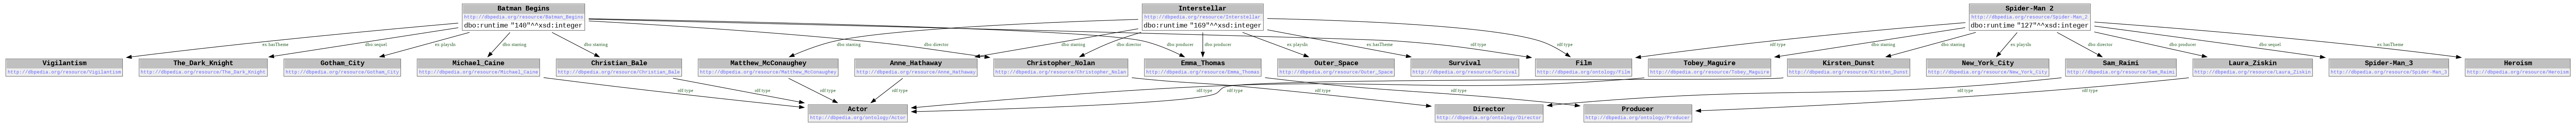

In [ ]:
visualize(g)

And finally a version with clickable links.

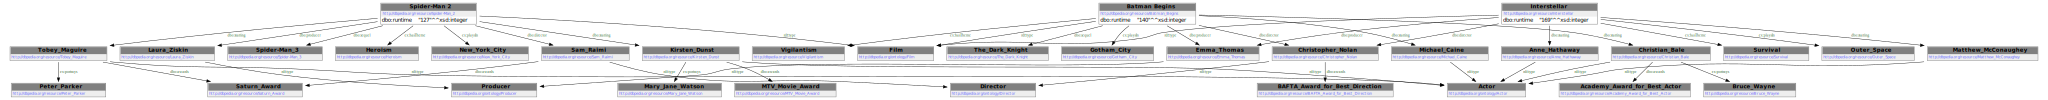

In [ ]:
from IPython.display import SVG, display

def visualize_svg_with_links(g):
    """Render RDFLib graph as SVG with clickable URIs (Graphviz required)."""
    stream = io.StringIO()
    rdf2dot(g, stream)
    dot = stream.getvalue()

    dg = pydotplus.graph_from_dot_data(dot)

    # Attach URL to nodes that look like HTTP URIs
    for node in dg.get_nodes():
        name = node.get_name().strip('"')
        if name.startswith("http"):
            node.set_URL(name)
            node.set_target("_blank")

    svg = dg.create_svg().decode("utf-8")
    display(SVG(svg))

visualize_svg_with_links(g)


## Graph Creation


*We* can look up information for a given URI.  
For example, let’s print all the facts about **Christian Bale**.

In [ ]:
chris = URIRef('http://dbpedia.org/resource/Christopher_Nolan')
# Print all predicate and objects of triples that have robert as subject
print([o for o in g.predicate_objects(subject=chris)])
print([o for o in g.subject_predicates(object=chris)])

[(rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://dbpedia.org/ontology/Director')), (rdflib.term.URIRef('http://dbpedia.org/ontology/awards'), rdflib.term.URIRef('http://dbpedia.org/resource/BAFTA_Award_for_Best_Direction'))]
[(rdflib.term.URIRef('http://dbpedia.org/resource/Batman_Begins'), rdflib.term.URIRef('http://dbpedia.org/ontology/director')), (rdflib.term.URIRef('http://dbpedia.org/resource/Interstellar'), rdflib.term.URIRef('http://dbpedia.org/ontology/director'))]


In [ ]:
from rdflib import Namespace

DBR = Namespace("http://dbpedia.org/resource/")
person = DBR.Christian_Bale

for s, p, o in g.triples((person, None, None)):
    print(p, o)


http://www.w3.org/1999/02/22-rdf-syntax-ns#type http://dbpedia.org/ontology/Actor
http://dbpedia.org/ontology/awards http://dbpedia.org/resource/Academy_Award_for_Best_Actor
http://example.org/portrays http://dbpedia.org/resource/Bruce_Wayne


Let's create a new simple graph and populate it with some information.

In [ ]:
DBR = Namespace("http://dbpedia.org/resource/")
DBO = Namespace("http://dbpedia.org/ontology/")
EX  = Namespace("http://example.org/")

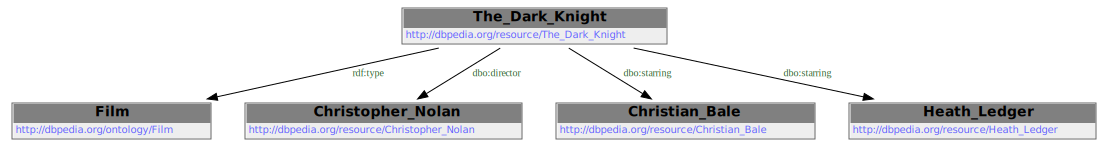

In [ ]:
# create new graph instance g1 and bind to namespaces
g1 = Graph()
g1.bind("dbr", DBR)
g1.bind("dbo", DBO)
g1.bind("ex", EX)

# exactly 5 URI nodes: film, class, director, two actors
g1.add((DBR.The_Dark_Knight, DBO.director, DBR.Christopher_Nolan))
g1.add((DBR.The_Dark_Knight, DBO.starring, DBR.Christian_Bale))
g1.add((DBR.The_Dark_Knight, DBO.starring, DBR.Heath_Ledger))
g1.add((DBR.The_Dark_Knight, RDF.type, DBO.Film))

visualize_svg_with_links(g1)

## Exercise 1 — Enrich the Dark Knight Graph

**Goal:** Add more facts to `g1` and re‑visualize.
Look them up from http://dbpedia.org/resource/The_Dark_Knight

**Pick any 3–5 proposals below and implement them:**
- Add `dbo:producer` (e.g., `dbr:Emma_Thomas`)
- Add `dbo:releaseDate` with an `xsd:date`
- Add `dbo:runtime` with an `xsd:integer`
- Add `dbo:genre` (e.g., `dbr:Crime_film`)
- Add `ex:hasTheme` (e.g., `dbr:Vigilantism`)
- Add `ex:playsIn` (e.g., `dbr:Gotham_City`)
- Add `ex:portrays` for actors (e.g., `dbr:Christian_Bale ex:portrays dbr:Bruce_Wayne`)

**Then:** run the visualization again.

<details>
<summary>Aufklappen: Lösung</summary>

```python
from rdflib.namespace import RDF, XSD

# Example additions (edit or extend)
g1.add((DBR.The_Dark_Knight, DBO.producer, DBR.Emma_Thomas))
g1.add((DBR.The_Dark_Knight, DBO.releaseDate, Literal("2008-07-18", datatype=XSD.date)))
g1.add((DBR.The_Dark_Knight, DBO.runtime, Literal(152, datatype=XSD.integer)))
g1.add((DBR.The_Dark_Knight, DBO.genre, DBR.Crime_film))
g1.add((DBR.The_Dark_Knight, EX.hasTheme, DBR.Vigilantism))
g1.add((DBR.The_Dark_Knight, EX.playsIn, DBR.Gotham_City))
g1.add((DBR.Christian_Bale, EX.portrays, DBR.Bruce_Wayne))

visualize_svg_with_links(g1)

```

In [ ]:
# Exercise 1 -- add your code here

## Exercise 2 — Model the Cast as an RDF Bag

**Goal:** Represent the cast as an unordered container.

**Tasks:**
1. Create a `rdf:Bag` container for the cast.
2. Link the film to the container using `ex:cast`.
3. Add at least three actors as `rdf:_1`, `rdf:_2`, `rdf:_3`.
4. Visualize the updated graph.

**Hint (RDFlib):** You may need a blank node. You can create a blank node with `BNode()` and use it like any other node.


<details>
<summary>Show solution</summary>

```python
from rdflib import BNode
from rdflib.namespace import RDF

cast = BNode()

g1.add((DBR.The_Dark_Knight, EX.cast, cast))
g1.add((cast, RDF.type, RDF.Bag))
g1.add((cast, RDF._1, DBR.Christian_Bale))
g1.add((cast, RDF._2, DBR.Heath_Ledger))
g1.add((cast, RDF._3, DBR.Michael_Caine))

visualize_svg_with_links(g1)
```

In [ ]:
# Exercise 2 -- add your code here

## Exercise 3 — Reception + Critique (Reification)

**Task:** Formalize the following text as RDF, and add a reception score.

**Text to formalize:**
> The Village Voice wrote that the performance would have made Ledger a legend even if he had lived.

**Also add:**
- A reception score of **94** from **Rotten Tomatoes**.

**Hints (relations to use):**
- `EX.receptionScore` for the Rotten Tomatoes number
- `EX.receptionSource` for the source (Rotten Tomatoes)
- Reification: `rdf:subject`, `rdf:predicate`, `rdf:object`
- `EX.source` for who said it (The Village Voice)
- `EX.comment` for the quote text

<details>
<summary>Show solution</summary>

```python
from rdflib import BNode, Literal
from rdflib.namespace import RDF, XSD

# Reception score
g1.add((DBR.The_Dark_Knight, EX.receptionScore, Literal(94, datatype=XSD.integer)))
g1.add((DBR.The_Dark_Knight, EX.receptionSource, DBR.Rotten_Tomatoes))

# Reified critique
stmt = BNode()
g1.add((stmt, RDF.type, RDF.Statement))
g1.add((stmt, RDF.subject, DBR.Heath_Ledger))
g1.add((stmt, RDF.predicate, EX.performance))
g1.add((stmt, RDF.object, DBR.Legendary_Performance))

g1.add((stmt, EX.source, DBR.The_Village_Voice))
g1.add((stmt, EX.comment, Literal(
    "The performance would have made Ledger a legend even if he had lived."
)))



In [ ]:
# Exercise 3 -- add your code here

## Exercise 4 — Literals, Datatypes, and Language Tags

**Goal:** Practice modeling *data values* in RDF.

**Tasks:**
1. Add a release date for the film as an `xsd:date`.
2. Add a runtime as an `xsd:integer`.
3. Add multilingual labels for the film (`@en` and `@de`).

**Hints (relations to use):**
- `dbo:releaseDate`
- `dbo:runtime`
- `rdfs:label`

<details>
<summary>Show solution</summary>

```python
from rdflib import Literal
from rdflib.namespace import XSD, RDFS

g1.add((DBR.The_Dark_Knight, DBO.releaseDate, Literal("2008-07-18", datatype=XSD.date)))
g1.add((DBR.The_Dark_Knight, DBO.runtime, Literal(152, datatype=XSD.integer)))

g1.add((DBR.The_Dark_Knight, RDFS.label, Literal("The Dark Knight", lang="en")))
g1.add((DBR.The_Dark_Knight, RDFS.label, Literal("The Dark Knight", lang="de")))


In [ ]:
# Exercise 4 -- add your code here

## Exercise 5 — Merge Two Graphs

**Goal:** Combine `g` and `g1` into a single graph mergedGraph.

**Tasks:**
1. Create a new graph `g2`.
2. Add all triples from `g` and `g1` into `mergedGraph`.
3. Print the triple count and visualize `mergedGraph`.

**Hints (Python functions):**
- Create a graph with `Graph()`
- Merge graphs with `mergedGraph += g` and `mergedGraph += g1`
- Count triples with `len(mergedGraph)`
- Bind the mergedGraph to the namespaces

<details>
<summary>Show solution</summary>

```python
from rdflib import Graph

mergedGraph = Graph()


mergedGraph.bind("dbo", DBO)
mergedGraph.bind("dbr", DBR)
mergedGraph.bind("ex", EX)
mergedGraph.bind("rdf", RDF)
mergedGraph.bind("rdfs", RDFS)

mergedGraph += g
mergedGraph += g1

print(f"Triples in mergedGraph: {len(mergedGraph)}")
visualize_svg_with_links(mergedGraph)


In [ ]:
# Exercise 5 -- add your code here

## Exercise 6 — Add a New Film to the Merged Graph

**Goal:** Enrich the merged graph with a new film and multilingual labels.

**Tasks:**
1. Create a URI for `dbr:Die_Hard`.
2. Add an English label (`@en`) and two other languages (`@de`, `@ua`).
3. Add a release date as an `xsd:date`.
4. Visualize the updated `mergedGraph`.

**Hints (functions & relations):**
- Use `Literal("text", lang="en")` for language tags
- Use `Literal("YYYY-MM-DD", datatype=XSD.date)` for dates
- Use `RDFS.label` and `DBO.releaseDate`
- Add triples with `mergedGraph.add((s, p, o))`

<details>
<summary>Show solution</summary>

```python
from rdflib import Literal, Namespace
from rdflib.namespace import RDFS, XSD

DBR = Namespace("http://dbpedia.org/resource/")
DBO = Namespace("http://dbpedia.org/ontology/")

diehard = DBR.Die_Hard

title_en = Literal("Die Hard", lang="en")
release_date = Literal("1988-07-15", datatype=XSD.date)

mergedGraph.add((diehard, RDFS.label, title_en))
mergedGraph.add((diehard, DBO.releaseDate, release_date))

mergedGraph.add((diehard, RDFS.label, Literal("Stirb langsam", lang="de")))
mergedGraph.add((diehard, RDFS.label, Literal("Міцний горішок", lang="ua")))

visualize_svg_with_links(mergedGraph)


In [ ]:
# Exercise 6 -- add your code here

## Exercise 7 — Add vs. Set (Multiple vs. Single Values)

**Goal:** Understand the difference between `add()` and `set()`.

**Tasks:**
1. Add two different release dates for `dbr:Die_Hard` using `add(...)`.
2. Print all release dates (you should see both).
3. Use `set(...)` to keep only **one** release date.
4. Print again and verify only one remains.

**Hints (functions):**
- `mergedGraph.add((s, p, o))` keeps existing values
- `mergedGraph.set((s, p, o))` replaces existing values
- Use `mergedGraph.objects(subject=diehard, predicate=DBO.releaseDate)` to list values

<details>
<summary>Show solution</summary>

```python
from rdflib import Literal
from rdflib.namespace import XSD

# Step 1: add two dates
mergedGraph.add((diehard, DBO.releaseDate, Literal("1988-07-15", datatype=XSD.date)))
mergedGraph.add((diehard, DBO.releaseDate, Literal("1988-07-22", datatype=XSD.date)))

print("After add:")
for date in mergedGraph.objects(subject=diehard, predicate=DBO.releaseDate):
    print(date)

# Step 3: replace with one date
mergedGraph.set((diehard, DBO.releaseDate, Literal("1988-07-22", datatype=XSD.date)))

print("After set:")
for date in mergedGraph.objects(subject=diehard, predicate=DBO.releaseDate):
    print(date)


In [ ]:
# Exercise 7 -- add your code here

## Exercise 8 — Migrate a Predicate (Schema Change)

Suppose you changed your schema (`releaseDate → releaseDateUSA`) and want the data to match.

**Tasks:**
1. Find all triples with `DBO.releaseDate`.
2. Replace them with `EX.releaseDateUSA`.
3. Verify that no `DBO.releaseDate` triples remain.

**Hints (functions):**
- Use `mergedGraph.triples((None, DBO.releaseDate, None))`
- Use `mergedGraph.add(...)` and `mergedGraph.remove(...)`
- Use `list(...)` to avoid modifying while iterating

<details>
<summary>Show solution</summary>

```python
# migrate predicate DBO.releaseDate -> EX.releaseDateUSA
for s, p, o in list(mergedGraph.triples((None, DBO.releaseDate, None))):
    mergedGraph.remove((s, DBO.releaseDate, o))
    mergedGraph.add((s, EX.releaseDateUSA, o))

# check: should be 0
print(len(list(mergedGraph.triples((None, DBO.releaseDate, None)))))


In [ ]:
# Exercise 8 -- add your code here

## Exercise 9 — Write a Function to Print Film Facts

**Goal:** Write a function that prints all predicate–object pairs for a film.

**Tasks:**
1. Write `print_film_facts(graph, film_uri)`.
2. Call it for **The Dark Knight** and **Spider‑Man 2**.

**Hints (functions):**
- Use `graph.predicate_objects(subject=film_uri)`
- Print each predicate–object pair on its own line

<details>
<summary>Show solution</summary>

```python
def print_film_facts(graph, film_uri):
    for p, o in graph.predicate_objects(subject=film_uri):
        print(p, o)

print("The Dark Knight")
print_film_facts(mergedGraph, DBR.The_Dark_Knight)

print("\nSpider-Man 2")
print_film_facts(mergedGraph, DBR["Spider-Man_2"])


In [ ]:
# Exercise 9 -- add your code here

## Exercise 10 — Undo a Change (Remove a Film)

Suppose you want to undo a change like adding **Die Hard**.  
Write a function that removes all triples about a film and confirms it’s gone.

**Tasks:**
1. Write `remove_film(graph, film_uri)` to delete all triples where the film is the subject.
2. Verify that no triples remain for that subject.

**Hints (functions):**
- Use `graph.remove((film_uri, None, None))`
- Check with a loop or `len(list(graph.triples((film_uri, None, None))))`

<details>
<summary>Show solution</summary>

```python
def remove_film(graph, film_uri):
    graph.remove((film_uri, None, None))

def has_film_triples(graph, film_uri):
    return len(list(graph.triples((film_uri, None, None)))) > 0

remove_film(mergedGraph, diehard)
print("Still present?", has_film_triples(mergedGraph, diehard))


In [ ]:
# Exercise 10 -- add your code here

## Exercise 11 — Serialize and Open in Protégé

**Goal:** Export the merged graph to RDF/XML and inspect it in Protégé.

**Tasks:**
1. Serialize `mergedGraph` to RDF/XML and save it as `mergedGraph.rdf`.
2. Open the file in Protégé and inspect the classes and individuals.

**Hints (functions):**
- Use `mergedGraph.serialize(destination="mergedGraph.rdf", format="xml")`

<details>
<summary>Show solution</summary>

```python
mergedGraph.serialize(destination="mergedGraph.rdf", format="xml")


## Protégé (Ontology Editor) -- Exercises

[Protégé](https://protege.stanford.edu/) is a free, widely used ontology editor for building and exploring RDF/OWL knowledge graphs.

**Please download and install Protégé** from the official website before the next session:  
https://protege.stanford.edu/

## Tasks

1. Open `mergedGraph.rdf`.  
   Can you find the individual `dbr:The_Dark_Knight`?

<details>
<summary>Show solution</summary>

In the **Individuals** tab, search for `The_Dark_Knight`.  
If prefixes are missing, it may show as a full URI or with `ns1:`.

</details>

2. What classes are visible in the **Classes** tab?  
   Which one is used for films?

<details>
<summary>Show solution</summary>

Look for `dbo:Film` (or `ns1:Film`).  
That is the class used for films.

</details>

3. In the **Individuals** tab, which actors appear?  
   Pick one and list all its properties.

<details>
<summary>Show solution</summary>

Example actors: `Tobey_Maguire`, `Christian_Bale`, `Heath_Ledger`.  
Click one to see properties like `rdf:type`, `ex:portrays`, `dbo:awards`.

</details>

4. Can you see multilingual labels (`rdfs:label`) for any film?  
   Which languages are shown?

<details>
<summary>Show solution</summary>

Example: `The Dark Knight` shows `@en` and `@de`.  
You’ll see language tags next to the label values.

</details>

5. Find the property `dbo:runtime`.  
   Which individuals have it, and what are the values?

<details>
<summary>Show solution</summary>

Films like `The_Dark_Knight`, `Interstellar`, and `Spider-Man_2` have it.  
Values are typed integers (e.g., 152, 169, 127).

</details>

6. Locate the blank node that represents the cast (`rdf:Bag`).  
   Which actors are contained?

<details>
<summary>Show solution</summary>

It appears as an anonymous node (blank node ID).  
Inside it you’ll see `rdf:_1`, `rdf:_2`, `rdf:_3` pointing to actors.

</details>

7. Check the `EX.receptionScore` of **The Dark Knight**.  
   What datatype is used?

<details>
<summary>Show solution</summary>

The value is `94` with datatype `xsd:integer`.

</details>

8. Add a new label in another language (e.g., `@es`) and save.  
   Does it appear in the RDF file?

<details>
<summary>Show solution</summary>

Yes. Open the exported file and confirm the new `rdfs:label` with `@es`.

</details>

9. Explore the Graph View in Protégé (OntoGraf)
<details> <summary>Show solution</summary>
Open the OntoGraf tab:
Window → Tabs → OntoGraf

Select a class or individual (e.g., dbo:Film) and click Add to the graph.

Expand neighbors to see related nodes and properties.

</details>

10. Enable the SPARQL tab and run your first query.

1. Go to `Window → Tabs → SPARQL` to enable the tab.  
2. Paste and run:

```sparql
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>

SELECT ?film ?director WHERE {
  ?film dbo:director ?director .
}
```

